In [49]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Path to your folder
DATA_PATH = r'C:\Users\sffra\Downloads\BSE 2025-2026\kosovo_nlp\scraped'

# 1. LIST FILES
print(f"Checking directory: {DATA_PATH}")
if not os.path.exists(DATA_PATH):
    print("ERROR: Directory does not exist!")
else:
    all_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.txt')]
    print(f"Found {len(all_files)} .txt files: {all_files}")

Checking directory: C:\Users\sffra\Downloads\BSE 2025-2026\kosovo_nlp\scraped
Found 2 .txt files: ['kos24.txt', 'kos25.txt']


In [50]:
import os
import re
import pandas as pd
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer
from gensim import corpora
from gensim.models import LdaModel

nltk.download('punkt')
stemmer = PorterStemmer()

# 1. Improved Extraction Function
def extract_text_robust(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        full_text = f.read()
    
    # Standardize whitespace to make searching easier
    clean_text = re.sub(r'\s+', ' ', full_text)
    
    # Find the start (1.1 CONTEXT)
    start_match = re.search(r"1\.1\.?\s*CONTEXT", clean_text, re.IGNORECASE)
    # Find the end (Section 2 / Cluster 1)
    end_match = re.search(r"2\.?\s*CLUSTER\s*1", clean_text, re.IGNORECASE)
    
    if not start_match or not end_match:
        # Fallback: Just take the first 10,000 characters if headers fail
        print(f"  [!] Headers not found in {os.path.basename(file_path)}. Using fallback.")
        return clean_text[0:10000]
    
    return clean_text[start_match.start():end_match.start()]

# 2. Processing and Stopwords
custom_stops = ['kosovo', 'european', 'from', 'with',
                'reform', 'implement', 'prepar', 'recommend', 'follow', 'some', 
    'action', 'continub', 'level', 'provid', 'activ', 'take', 'made',
    'work', 'process', 'period', 'capac', 'bodi', 'use', 'good', 'commission', 'report', 'year', 'progress', 'also', 'further']

all_docs = []
doc_labels = []

for f_name in ['kos24.txt', 'kos25.txt']:
    path = os.path.join(DATA_PATH, f_name)
    if os.path.exists(path):
        raw_section = extract_text_robust(path)
        
        # Split into chunks of 5 sentences
        sentences = sent_tokenize(raw_section)
        chunks = [" ".join(sentences[i:i + 5]) for i in range(0, len(sentences), 5)]
        
        for chunk in chunks:
            tokens = word_tokenize(chunk.lower())
            stemmed = [stemmer.stem(t) for t in tokens if t.isalpha() 
                       and t not in custom_stops and len(t) > 3]
            if len(stemmed) > 5:
                all_docs.append(stemmed)
                doc_labels.append(f_name)

# 3. LDA with Error Handling
if len(all_docs) > 0:
    print(f"Success! Dictionary contains {len(all_docs)} chunks.")
    dictionary = corpora.Dictionary(all_docs)
    corpus = [dictionary.doc2bow(d) for d in all_docs]
    
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=3, passes=20, random_state=42)
    
    print("\n--- TOPICS DISCOVERED ---")
    for idx, topic in lda.print_topics(-1):
        print(f"Topic {idx}: {topic}\n")
else:
    print("ERROR: all_docs is still empty. Please check if the .txt files contain text.")

  [!] Headers not found in kos24.txt. Using fallback.
  [!] Headers not found in kos25.txt. Using fallback.
Success! Dictionary contains 26 chunks.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sffra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!



--- TOPICS DISCOVERED ---
Topic 0: 0.015*"implement" + 0.013*"assembl" + 0.011*"polit" + 0.010*"recommend" + 0.010*"legisl" + 0.009*"under" + 0.009*"adopt" + 0.009*"integr" + 0.009*"improv" + 0.009*"need"

Topic 1: 0.018*"prepar" + 0.013*"includ" + 0.011*"govern" + 0.009*"reform" + 0.009*"assess" + 0.009*"council" + 0.009*"use" + 0.009*"judiciari" + 0.009*"state" + 0.007*"consult"

Topic 2: 0.019*"public" + 0.013*"administr" + 0.012*"fundament" + 0.012*"implement" + 0.012*"elect" + 0.011*"civil" + 0.011*"prepar" + 0.009*"remain" + 0.008*"judiciari" + 0.008*"servic"



In [51]:
# 1. Create a list of results
regression_data = []

for i, bow in enumerate(corpus):
    # Get the weight for each topic
    weights = dict(lda.get_document_topics(bow))
    
    # Extract year from the filename
    year = 2024 if "24" in doc_labels[i] else 2025
    
    row = {
        'Chunk_ID': i,
        'Year': year,
        'Political_Inst_Weight': weights.get(0, 0),
        'Strategic_Integr_Weight': weights.get(1, 0),
        'Admin_RuleOfLaw_Weight': weights.get(2, 0)
    }
    regression_data.append(row)

# 2. Convert to DataFrame
df_final = pd.DataFrame(regression_data)

# 3. Simple Visual Check
print("Average Topic Weights by Year:")
print(df_final.groupby('Year').mean()[['Political_Inst_Weight', 'Strategic_Integr_Weight', 'Admin_RuleOfLaw_Weight']])

# 4. Save to CSV
df_final.to_csv("kosovo_lda_results.csv", index=False)
print("\nCSV saved as 'kosovo_lda_results.csv'. You can now run a regression on these weights!")

Average Topic Weights by Year:
      Political_Inst_Weight  Strategic_Integr_Weight  Admin_RuleOfLaw_Weight
Year                                                                        
2024               0.456405                 0.152847                0.378974
2025               0.330116                 0.229434                0.429864

CSV saved as 'kosovo_lda_results.csv'. You can now run a regression on these weights!


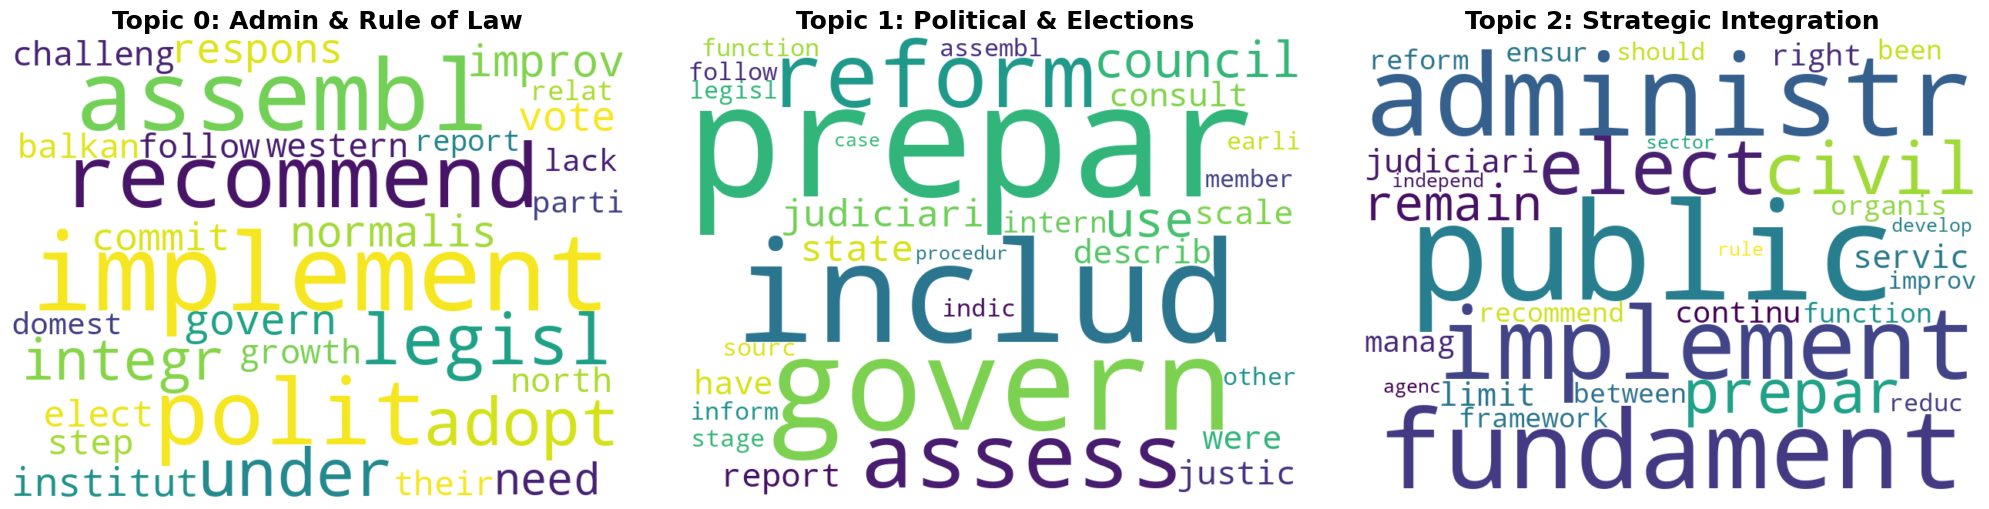

In [52]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_topic_wordclouds(lda_model, num_topics):
    # Set up the figure
    fig, axes = plt.subplots(1, num_topics, figsize=(20, 10), sharex=True, sharey=True)
    
    # Topic Titles for your specific project
    topic_titles = [
        "Topic 0: Admin & Rule of Law",
        "Topic 1: Political & Elections",
        "Topic 2: Strategic Integration"
    ]

    for i, ax in enumerate(axes.flatten()):
        fig.add_subplot(ax)
        
        # Get dictionary of word frequencies for the topic
        # lda_model.show_topic returns a list of (word, probability)
        topic_words = dict(lda_model.show_topic(i, 30))
        
        # Generate the word cloud
        cloud = WordCloud(background_color='white',
                          width=800,
                          height=600,
                          max_words=30,
                          colormap='viridis',
                          prefer_horizontal=1.0)
        
        cloud.generate_from_frequencies(topic_words)
        
        # Display
        ax.imshow(cloud, interpolation='bilinear')
        ax.set_title(topic_titles[i], fontsize=18, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1)
    plt.show()

# Run the function
generate_topic_wordclouds(lda, num_topics=3)

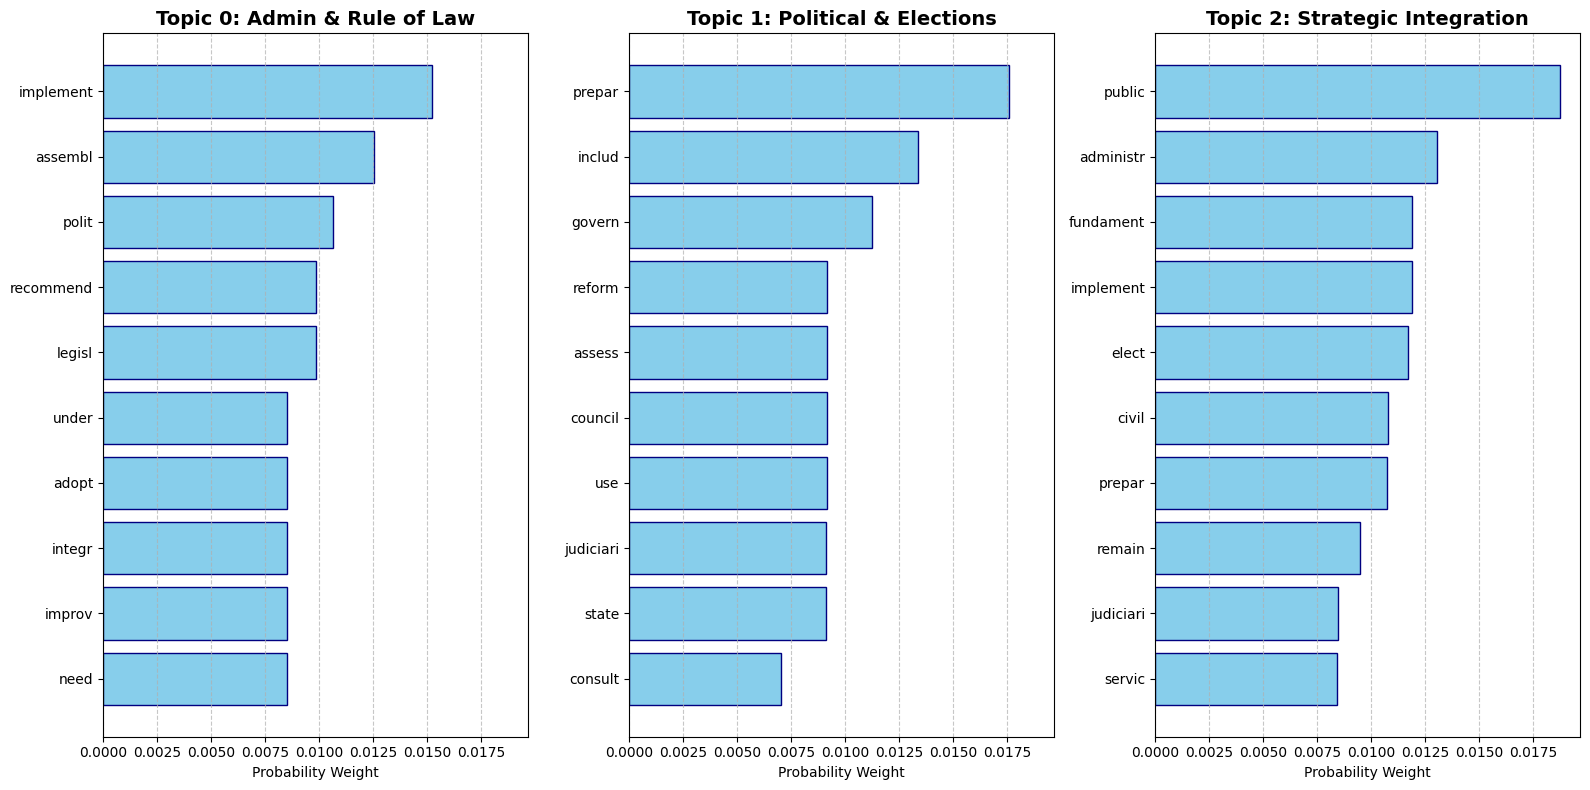

In [54]:
import matplotlib.pyplot as plt

def plot_gensim_topics(lda_model, num_topics=3, n_words=10):
    # Set up the subplot structure
    fig, axes = plt.subplots(1, num_topics, figsize=(16, 8), sharex=True)
    axes = axes.flatten()
    
    # Custom titles based on our previous analysis
    titles = ["Topic 0: Admin & Rule of Law", 
              "Topic 1: Political & Elections", 
              "Topic 2: Strategic Integration"]
    
    for i in range(num_topics):
        # Extract the top words and their probabilities from Gensim
        topic_data = lda_model.show_topic(i, topn=n_words)
        words = [word for word, prob in topic_data]
        probs = [prob for word, prob in topic_data]
        
        # Plotting
        ax = axes[i]
        ax.barh(words, probs, color='skyblue', edgecolor='navy')
        ax.set_title(titles[i], fontsize=14, fontweight='bold')
        ax.invert_yaxis()  # Put the highest probability at the top
        ax.set_xlabel('Probability Weight')
        ax.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Run the visualization
plot_gensim_topics(lda)